# SkillCraft Technology – Data Science Internship

## Task 1: Data Visualization

### Population Analysis (1960–2025)

**Dataset:** World Bank Population Data

**Objective:** Visualize the distribution of population data and identify the 10 most populated countries in 2025.

In [ ]:
import zipfile
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
zip_file = "API_SP.POP.TOTL_DS2_en_xml_v2_10296.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("population_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
xml_file = "population_data/API_SP.POP.TOTL_DS2_en_xml_v2_10296.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

records = []

for record in root.iter("record"):
    fields = [field.text for field in record.findall("field")]
    records.append(fields)

df = pd.DataFrame(
    records,
    columns=["Country", "Indicator", "Year", "Population"]
)

df.head()

,Country,Indicator,Year,Population
0,Aruba,"Population, total",1960,54922
1,Aruba,"Population, total",1961,55578
2,Aruba,"Population, total",1962,56320
3,Aruba,"Population, total",1963,57002
4,Aruba,"Population, total",1964,57619


In [ ]:
# Convert Year and Population to numeric values
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

# Remove rows with missing population values
df = df.dropna(subset=["Population"])

# Check the cleaned dataset
print("Number of rows:", len(df))
print("Number of countries:", df["Country"].nunique())
print("Year range:", df["Year"].min(), "-", df["Year"].max())

df.head()

Number of rows: 17394
Number of countries: 264
Year range: 1960 - 2025


,Country,Indicator,Year,Population
0,Aruba,"Population, total",1960,54922.0
1,Aruba,"Population, total",1961,55578.0
2,Aruba,"Population, total",1962,56320.0
3,Aruba,"Population, total",1963,57002.0
4,Aruba,"Population, total",1964,57619.0


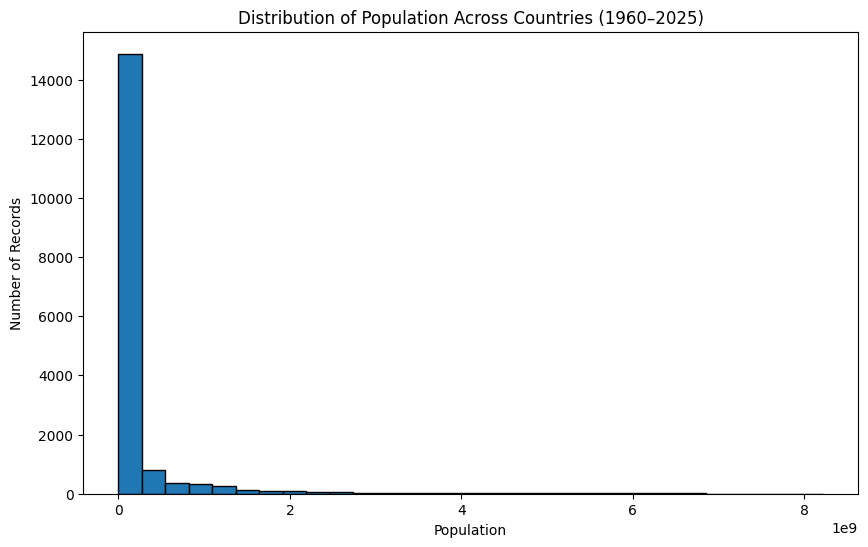

In [ ]:
# Create a histogram of population distribution

plt.figure(figsize=(10, 6))

plt.hist(df["Population"], bins=30, edgecolor="black")

plt.title("Distribution of Population Across Countries (1960–2025)")
plt.xlabel("Population")
plt.ylabel("Number of Records")

plt.show()

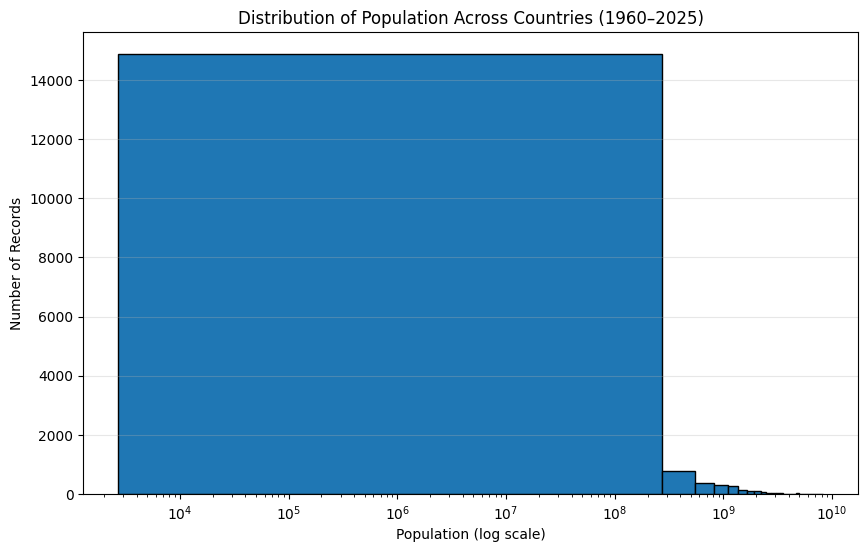

In [ ]:
# Create a clearer population distribution using a logarithmic x-axis

plt.figure(figsize=(10, 6))

plt.hist(df["Population"], bins=30, edgecolor="black")

plt.xscale("log")

plt.title("Distribution of Population Across Countries (1960–2025)")
plt.xlabel("Population (log scale)")
plt.ylabel("Number of Records")

plt.grid(axis="y", alpha=0.3)

plt.show()

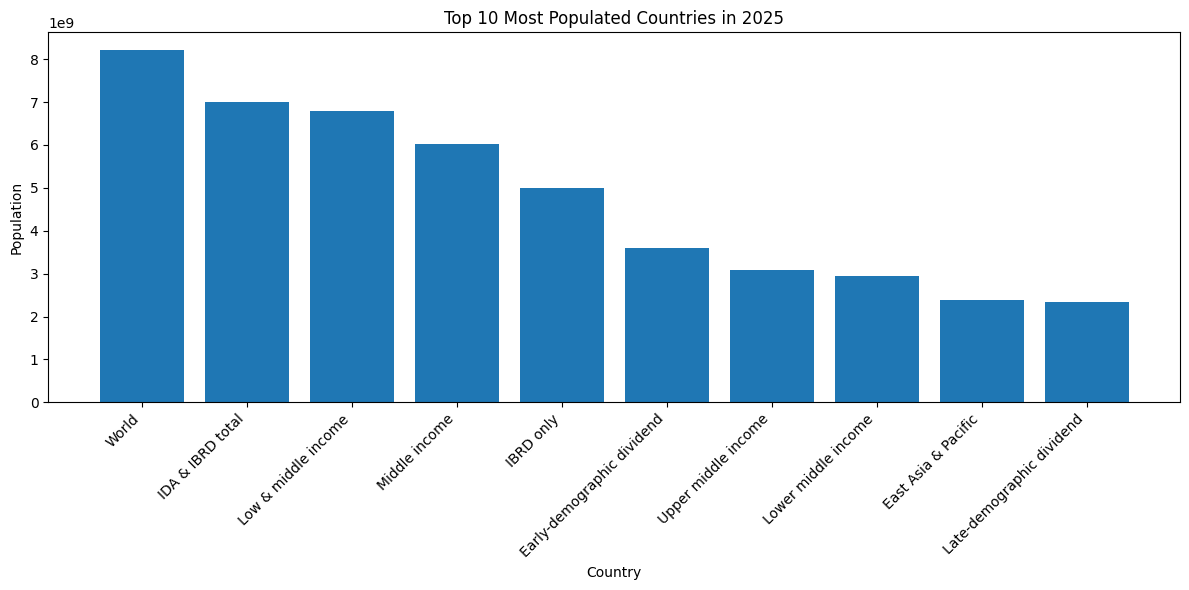

In [ ]:
# Filter data for 2025
df_2025 = df[df["Year"] == 2025].copy()

# Select the 10 most populated countries
top_10 = df_2025.nlargest(10, "Population")

# Create the bar chart
plt.figure(figsize=(12, 6))

plt.bar(top_10["Country"], top_10["Population"])

plt.title("Top 10 Most Populated Countries in 2025")
plt.xlabel("Country")
plt.ylabel("Population")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

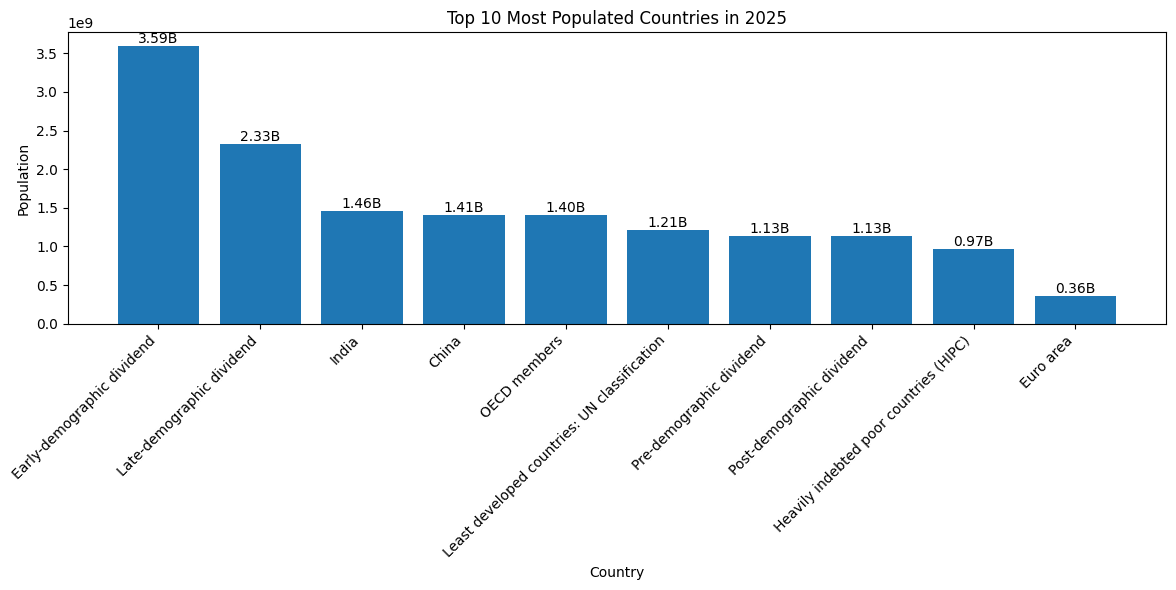

In [ ]:
# Filter data for 2025
df_2025 = df[df["Year"] == 2025].copy()

# Remove World Bank regional/income aggregates
aggregate_keywords = [
    "World",
    "income",
    "IBRD",
    "IDA",
    "division",
    "region",
    "Africa",
    "Asia",
    "Europe",
    "Pacific",
    "America",
    "Caribbean",
    "Middle East"
]

country_data = df_2025[
    ~df_2025["Country"].str.contains(
        "|".join(aggregate_keywords),
        case=False,
        na=False
    )
].copy()

# Select the 10 most populated countries
top_10 = country_data.nlargest(10, "Population")

# Create the bar chart
plt.figure(figsize=(12, 6))

bars = plt.bar(top_10["Country"], top_10["Population"])

plt.title("Top 10 Most Populated Countries in 2025")
plt.xlabel("Country")
plt.ylabel("Population")

plt.xticks(rotation=45, ha="right")

# Add population labels
for bar, population in zip(bars, top_10["Population"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{population/1e9:.2f}B",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Install and import the country-name library
!pip -q install pycountry

import pycountry

# Get recognized country names
country_names = set()

for country in pycountry.countries:
    country_names.add(country.name.lower())

    if hasattr(country, "official_name"):
        country_names.add(country.official_name.lower())

# Handle common World Bank country-name differences
country_names.update([
    "united states",
    "russian federation",
    "iran, islamic rep.",
    "egypt, arab rep.",
    "venezuela, rb",
    "korea, rep.",
    "korea, dem. people's rep.",
    "turkiye"
])

# Filter 2025 data
df_2025 = df[df["Year"] == 2025].copy()

# Keep only recognized countries
country_data = df_2025[
    df_2025["Country"].str.lower().isin(country_names)
].copy()

# Find the 10 most populated countries
top_10 = country_data.nlargest(10, "Population")

print("Top 10 countries:")
print(top_10[["Country", "Population"]])

Top 10 countries:
                  Country    Population
7193                India  1.463866e+09
2705                China  1.406585e+09
16565       United States  3.417849e+08
6995            Indonesia  2.857212e+08
12143            Pakistan  2.552196e+08
11483             Nigeria  2.375278e+08
1979               Brazil  2.128124e+08
1385           Bangladesh  1.756869e+08
13331  Russian Federation  1.435133e+08
4817             Ethiopia  1.354721e+08


In [ ]:
# Keep only actual country names recognized by pycountry
def is_country(name):
    try:
        return pycountry.countries.lookup(name) is not None
    except LookupError:
        return False

country_data = df_2025[
    df_2025["Country"].apply(is_country)
].copy()

# Get the top 10 countries
top_10 = country_data.nlargest(10, "Population")

print("Top 10 actual countries:")
print(top_10[["Country", "Population"]])

Top 10 actual countries:
                  Country    Population
7193                India  1.463866e+09
2705                China  1.406585e+09
16565       United States  3.417849e+08
6995            Indonesia  2.857212e+08
12143            Pakistan  2.552196e+08
11483             Nigeria  2.375278e+08
1979               Brazil  2.128124e+08
1385           Bangladesh  1.756869e+08
13331  Russian Federation  1.435133e+08
4817             Ethiopia  1.354721e+08


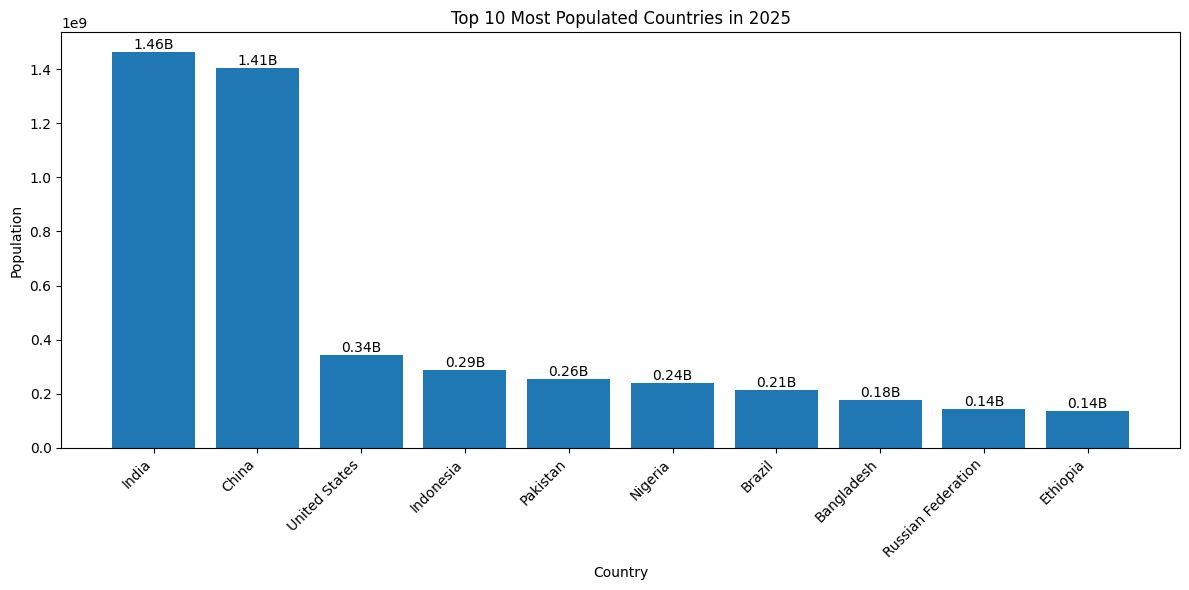

In [ ]:
# Final bar chart: Top 10 most populated countries in 2025

plt.figure(figsize=(12, 6))

bars = plt.bar(top_10["Country"], top_10["Population"])

plt.title("Top 10 Most Populated Countries in 2025")
plt.xlabel("Country")
plt.ylabel("Population")

plt.xticks(rotation=45, ha="right")

# Add population labels above each bar
for bar, population in zip(bars, top_10["Population"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{population / 1e9:.2f}B",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Analysis

The bar chart shows the 10 most populated countries in 2025 based on the dataset.

India has the highest population at approximately 1.46 billion, followed by China at approximately 1.41 billion. The United States ranks third with around 342 million people.

Indonesia, Pakistan, and Nigeria are also among the most populous countries, each having more than 200 million people. Brazil and Bangladesh have populations below 200 million, while the Russian Federation and Ethiopia have populations of approximately 144 million and 135 million respectively.

The chart shows a significant population gap between the two most populous countries and the remaining countries in the top 10.

## Conclusion

The visualization highlights the large differences in population size among the world's most populous countries. India and China have populations far greater than the other countries in the top 10, while the remaining countries are comparatively smaller.